# Destino das Exportações de Roupas Usadas — European Environment Agency

Este notebook analisa dados da European Environment Agency (EEA) sobre os destinos das exportações europeias de roupas usadas.

O objetivo é identificar como a distribuição geográfica desses fluxos comerciais se modificou ao longo do tempo.

## 1. Objetivo da análise

Analisar a distribuição regional das exportações de roupas usadas da União Europeia entre 2000 e 2019.

A análise permite observar quais regiões receberam maiores parcelas dessas exportações e como essa distribuição mudou ao longo do período.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Carregamento dos dados

Os dados utilizados foram disponibilizados pela European Environment Agency (EEA) e apresentam a distribuição percentual dos destinos das exportações europeias de roupas usadas.

In [4]:
eea_data = pd.read_excel(
    "FIG3-159956-EU-exports-v5-Data.xlsx"
)

display(eea_data.head(10))

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,NaN,NaN,NaN,NaN
1,Data,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,2000.0,2010.0,2019.0
4,Africa,63.0,54.0,46.0
5,Asia,26.0,33.0,41.0
6,Europe (non-EU),8.0,12.0,11.0
7,South America,2.0,1.0,1.0
8,North America,1.0,1.0,0.0
9,Oceania,0.0,0.0,0.0


## 3. Preparação dos dados

Foram selecionadas as regiões de destino e os anos disponíveis para comparação.

In [5]:
eea_destinos = eea_data.iloc[4:9, 0:4].copy()

eea_destinos.columns = [
    "Destino",
    "2000",
    "2010",
    "2019"
]

for coluna in ["2000", "2010", "2019"]:
    eea_destinos[coluna] = pd.to_numeric(
        eea_destinos[coluna],
        errors="coerce"
    )

display(eea_destinos)

,Destino,2000,2010,2019
4,Africa,63.0,54.0,46.0
5,Asia,26.0,33.0,41.0
6,Europe (non-EU),8.0,12.0,11.0
7,South America,2.0,1.0,1.0
8,North America,1.0,1.0,0.0


## 4. Organização dos dados para análise

Os dados foram reorganizados para facilitar a construção de gráficos e a comparação entre os diferentes anos.

In [6]:
eea_destinos_melt = eea_destinos.melt(
    id_vars="Destino",
    var_name="Ano",
    value_name="Percentual"
)

eea_destinos_melt["Ano"] = pd.to_numeric(
    eea_destinos_melt["Ano"]
)

display(eea_destinos_melt)

,Destino,Ano,Percentual
0,Africa,2000,63.0
1,Asia,2000,26.0
2,Europe (non-EU),2000,8.0
3,South America,2000,2.0
4,North America,2000,1.0
5,Africa,2010,54.0
6,Asia,2010,33.0
7,Europe (non-EU),2010,12.0
8,South America,2010,1.0
9,North America,2010,1.0


## 5. Evolução dos destinos das exportações

O gráfico apresenta a participação percentual de cada região no destino das exportações europeias de roupas usadas.

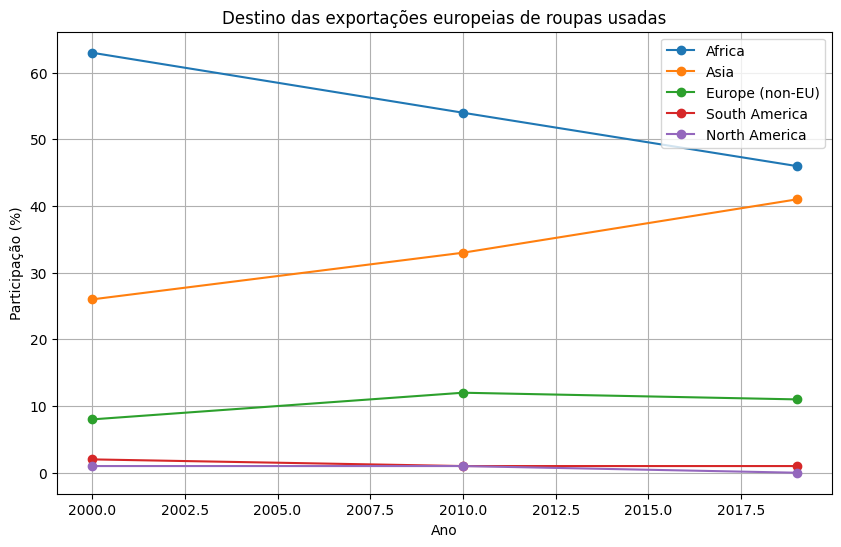

In [7]:
plt.figure(figsize=(10,6))

for destino in eea_destinos["Destino"]:

    dados = eea_destinos_melt[
        eea_destinos_melt["Destino"] == destino
    ]

    plt.plot(
        dados["Ano"],
        dados["Percentual"],
        marker="o",
        label=destino
    )

plt.title(
    "Destino das exportações europeias de roupas usadas"
)

plt.xlabel("Ano")
plt.ylabel("Participação (%)")

plt.legend()
plt.grid(True)

plt.show()

## 6. Variação entre 2000 e 2019

Nesta etapa é calculada a variação em pontos percentuais da participação de cada região entre 2000 e 2019.

In [8]:
eea_destinos["Variação_2000_2019"] = (
    eea_destinos["2019"] -
    eea_destinos["2000"]
)

display(eea_destinos)

,Destino,2000,2010,2019,Variação_2000_2019
4,Africa,63.0,54.0,46.0,-17.0
5,Asia,26.0,33.0,41.0,15.0
6,Europe (non-EU),8.0,12.0,11.0,3.0
7,South America,2.0,1.0,1.0,-1.0
8,North America,1.0,1.0,0.0,-1.0


## 7. Principais resultados

Os dados indicam mudanças importantes na distribuição geográfica das exportações europeias de roupas usadas.

A participação da África caiu de 63% em 2000 para 46% em 2019, enquanto a participação da Ásia aumentou de 26% para 41%.

Esses resultados mostram que os destinos das roupas usadas não permaneceram estáticos ao longo do período.

É importante destacar que o percentual de exportações destinadas a uma região não representa diretamente a quantidade de roupas que se transformou em resíduos nessa região. Os dados indicam fluxos comerciais e não o destino final de cada peça.